# Titanic — EDA & Feature Engineering

**Author:** baidarbe01EDU_Astana_03_2026

## Iteration history

| Iteration | Features | Best Kaggle |
|---|---|---|
| 1 | Label encoding Title/Embarked, many features | 0.799 |
| 2 | One-hot encoding, many features | 0.804 |
| 3 | Leakage fix attempt, many features | 0.797 |
| 4 | Two pipelines A/B (no family vs fixed family) | 0.797 |
| 5 (this) | Konstantin's exact 6 features — proven 0.82-0.83 | TBD |

**What went wrong in iterations 1–4:**  
Too many features. `Name_Length`, `Ticket_Frequency`, `Child`, `Senior`, `Embarked`, one-hot Title columns — all added noise without signal. More features ≠ better model. The curse of dimensionality means irrelevant features hurt distance-based models like KNN.

**This iteration:** Rebuild using Konstantin Masich's exact minimal feature set — 6 features that achieved 0.82-0.83 on Kaggle.  
Source: https://www.kaggle.com/konstantinmasich/titanic-0-82-0-83

## Learning Objectives
- Feature engineering: less is more — quality over quantity
- Why Embarked has no impact despite looking meaningful in EDA
- Why FareBin/AgeBin are label encoded (ordinal), not one-hot
- Family_Survival: how group dynamics predicted survival
- KNN with StandardScaler: why scaling is critical for distance-based models
- Cross-validation, GridSearchCV, evaluation metrics

---
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('../scripts'))
from preprocessing import build_features
print('Custom scripts imported successfully!')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_style('whitegrid')
%matplotlib inline
print('All imports successful!')

Custom scripts imported successfully!
All imports successful!


---
## 2. Load Data

In [3]:
train_df = pd.read_csv('../data/train.csv')
test_df  = pd.read_csv('../data/test.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Dataset columns:**
- `Survived` — target (0=Died, 1=Survived)
- `Pclass` — ticket class (1=Upper, 2=Middle, 3=Lower)
- `Name`, `Sex`, `Age`
- `SibSp` — # siblings/spouses aboard
- `Parch` — # parents/children aboard
- `Ticket`, `Fare`, `Cabin`
- `Embarked` — port (C=Cherbourg, Q=Queenstown, S=Southampton)

---
## 3. Exploratory Data Analysis (EDA)

**What is EDA?** Systematically exploring the data to understand structure, find patterns, and form hypotheses before building a model. For Titanic, we ask: who survived and why?

Key questions:
- Which features have missing values and how should we fill them?
- Which features correlate most strongly with survival?
- What hypotheses can we form to guide feature engineering?

In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
missing     = train_df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})[missing > 0]

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [6]:
print(f"Survival rate: {train_df['Survived'].mean():.2%}")
print(f"Died: {(train_df['Survived']==0).sum()} | Survived: {(train_df['Survived']==1).sum()}")

Survival rate: 38.38%
Died: 549 | Survived: 342


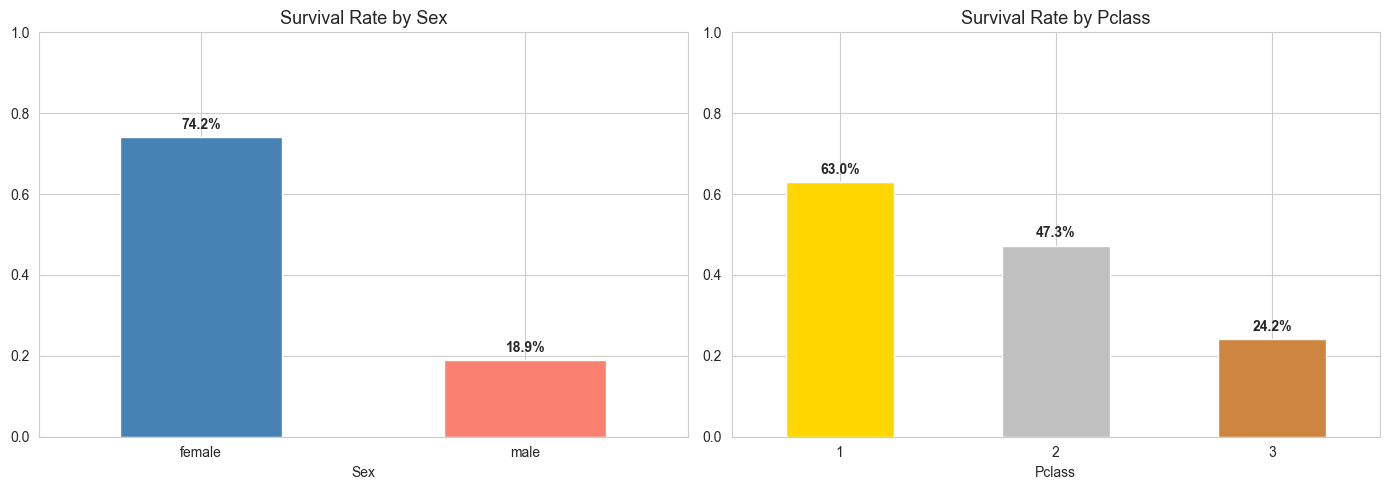

INSIGHT: Female 74% vs male 19%. 1st class 63% vs 3rd class 24%.
Both Pclass and Sex are kept in the final feature set.


In [7]:
# Sex and Pclass — two of the strongest features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_surv = train_df.groupby('Sex')['Survived'].mean()
sex_surv.plot(kind='bar', ax=axes[0], color=['steelblue','salmon'], rot=0)
axes[0].set_title('Survival Rate by Sex', fontsize=13)
axes[0].set_ylim(0, 1)
for i, v in enumerate(sex_surv):
    axes[0].text(i, v+0.02, f'{v:.1%}', ha='center', fontweight='bold')

pclass_surv = train_df.groupby('Pclass')['Survived'].mean()
pclass_surv.plot(kind='bar', ax=axes[1], color=['gold','silver','peru'], rot=0)
axes[1].set_title('Survival Rate by Pclass', fontsize=13)
axes[1].set_ylim(0, 1)
for i, v in enumerate(pclass_surv):
    axes[1].text(i, v+0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print('INSIGHT: Female 74% vs male 19%. 1st class 63% vs 3rd class 24%.')
print('Both Pclass and Sex are kept in the final feature set.')

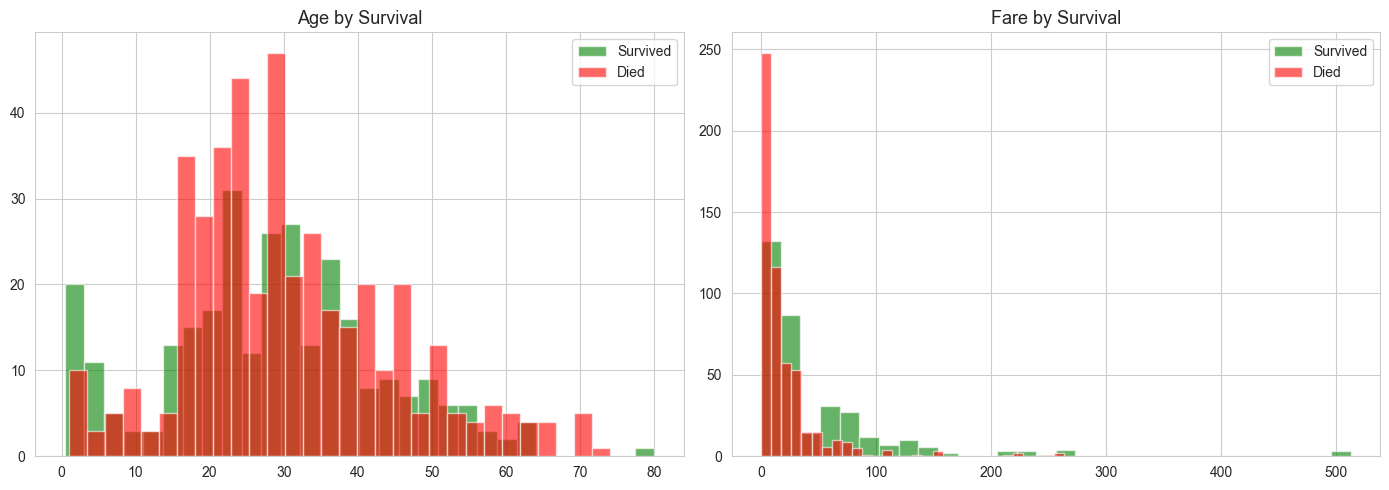

Age: 177 missing — imputed by Title group median.
Both Age and Fare are binned into quantile groups (4 and 5 bins respectively).
Bins are label encoded (0,1,2,3) because higher bin = higher fare/age = ordinal.


In [8]:
# Age and Fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color in [(1,'green'),(0,'red')]:
    lbl = 'Survived' if label else 'Died'
    train_df[train_df['Survived']==label]['Age'].dropna().hist(
        ax=axes[0], bins=30, alpha=0.6, color=color, label=lbl)
    train_df[train_df['Survived']==label]['Fare'].hist(
        ax=axes[1], bins=30, alpha=0.6, color=color, label=lbl)
axes[0].set_title('Age by Survival', fontsize=13)
axes[0].legend()
axes[1].set_title('Fare by Survival', fontsize=13)
axes[1].legend()
plt.tight_layout()
plt.show()
print(f'Age: {train_df["Age"].isnull().sum()} missing — imputed by Title group median.')
print('Both Age and Fare are binned into quantile groups (4 and 5 bins respectively).')
print('Bins are label encoded (0,1,2,3) because higher bin = higher fare/age = ordinal.')

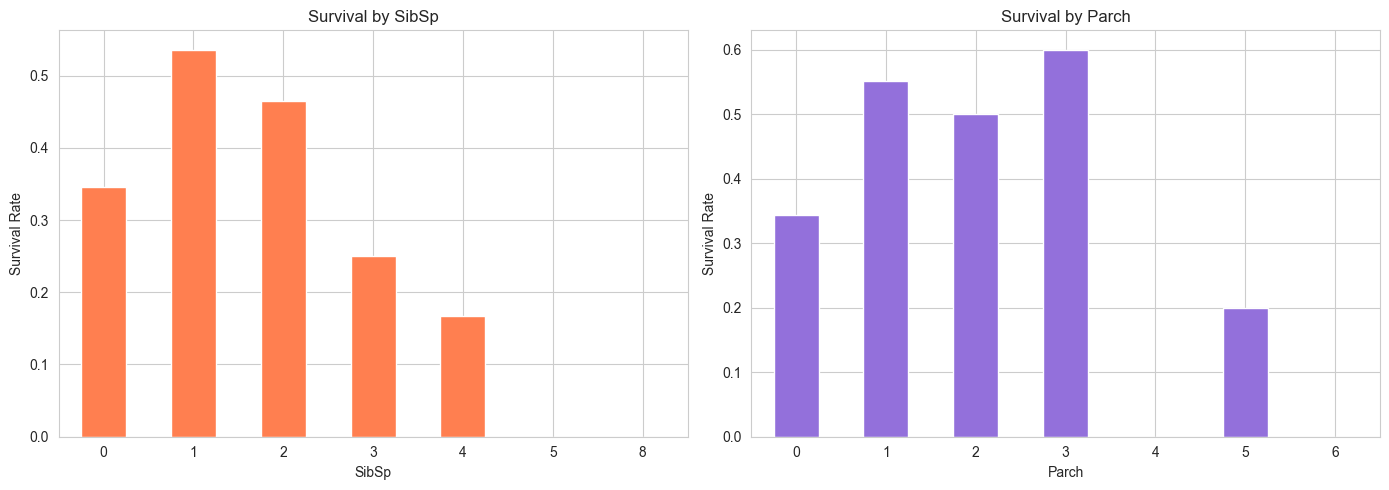

Small families survived better. SibSp and Parch combined into Family_Size = SibSp + Parch.
NOTE: No +1 in this pipeline — matches Konstantin kernel exactly.


In [9]:
# Family features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_df.groupby('SibSp')['Survived'].mean().plot(kind='bar', ax=axes[0], rot=0, color='coral')
axes[0].set_title('Survival by SibSp', fontsize=12)
axes[0].set_ylabel('Survival Rate')
train_df.groupby('Parch')['Survived'].mean().plot(kind='bar', ax=axes[1], rot=0, color='mediumpurple')
axes[1].set_title('Survival by Parch', fontsize=12)
axes[1].set_ylabel('Survival Rate')
plt.tight_layout()
plt.show()
print('Small families survived better. SibSp and Parch combined into Family_Size = SibSp + Parch.')
print('NOTE: No +1 in this pipeline — matches Konstantin kernel exactly.')

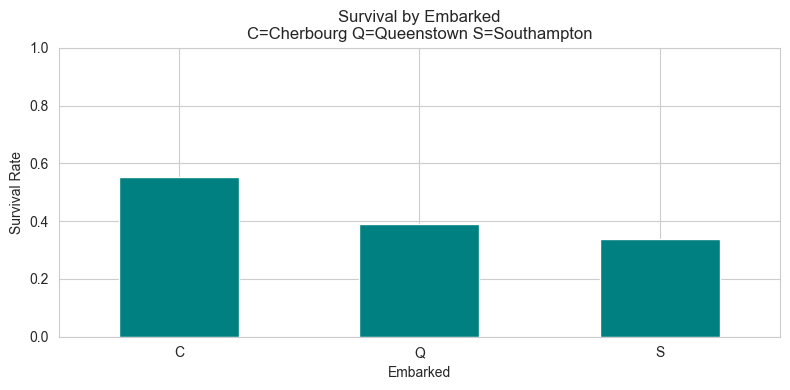

Embarked LOOKS meaningful here — but Konstantin confirmed it has no real impact.
The signal is a proxy for Pclass (more 1st class boarded at Cherbourg).
Once Pclass is in the model, Embarked adds nothing. It is DROPPED.


In [10]:
# Embarked — looks meaningful but is NOT used
emb_surv = train_df.groupby('Embarked')['Survived'].mean()
emb_surv.plot(kind='bar', color='teal', rot=0, figsize=(8,4))
plt.title('Survival by Embarked\nC=Cherbourg Q=Queenstown S=Southampton', fontsize=12)
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
print('Embarked LOOKS meaningful here — but Konstantin confirmed it has no real impact.')
print('The signal is a proxy for Pclass (more 1st class boarded at Cherbourg).')
print('Once Pclass is in the model, Embarked adds nothing. It is DROPPED.')

---
## 4. Feature Engineering

**What makes a good feature?** It encodes real information about survival that is not already captured by other features, and it generalises to unseen data.

**Lesson from iterations 1–4:** Adding more features hurt the model. `Name_Length`, `Ticket_Frequency`, `Child`, `Senior`, all the one-hot Title/Embarked columns — they added dimensions without adding signal. KNN suffers especially from this (curse of dimensionality — in high dimensions, all points become equidistant).

**Konstantin's 6 features and why each one earns its place:**

| Feature | Why kept |
|---|---|
| `Pclass` | Direct proxy for socioeconomic status — determines lifeboat access |
| `Sex` | Strongest single predictor — women first protocol |
| `Family_Size` | Group dynamics — small families coordinated better |
| `Family_Survival` | Most impactful engineered feature — group fates were correlated |
| `FareBin_Code` | Ordinal proxy for wealth — more granular than Pclass |
| `AgeBin_Code` | Age group affects survival — children prioritised |

**Why FareBin and AgeBin are label encoded (not one-hot):**  
These bins are ordinal — FareBin=3 genuinely means higher fare than FareBin=1. Label encoding preserves this ordering. One-hot would treat them as independent unordered categories, losing the ordinal relationship.

**Why Embarked is dropped:**  
Its survival signal is a proxy for Pclass — passengers from Cherbourg survived more because more 1st class boarded there. Once Pclass is in the model, Embarked adds no new information. Keeping it just adds noise.

All engineering is in `scripts/preprocessing.py` — the notebook, `train.py`, and `predict.py` all call the same `build_features()` function.

In [11]:
X_train, y_train, X_test = build_features(train_df, test_df)
print(f'\nX_train: {X_train.shape} | X_test: {X_test.shape}')
X_train.head()

  Pass 1 — passengers with family info: 420
  Pass 2 — passengers with family/group info: 546

  Features (6): ['Pclass', 'Sex', 'Family_Size', 'Family_Survival', 'FareBin_Code', 'AgeBin_Code']
  X_train: (891, 6) | X_test: (418, 6)
  Missing in X_train: 0

X_train: (891, 6) | X_test: (418, 6)


,Pclass,Sex,Family_Size,Family_Survival,FareBin_Code,AgeBin_Code
0,3,0,1,0.5,0,0
1,1,1,1,0.5,4,3
2,3,1,0,0.5,1,1
3,1,1,1,0.0,4,2
4,3,0,0,0.5,1,2


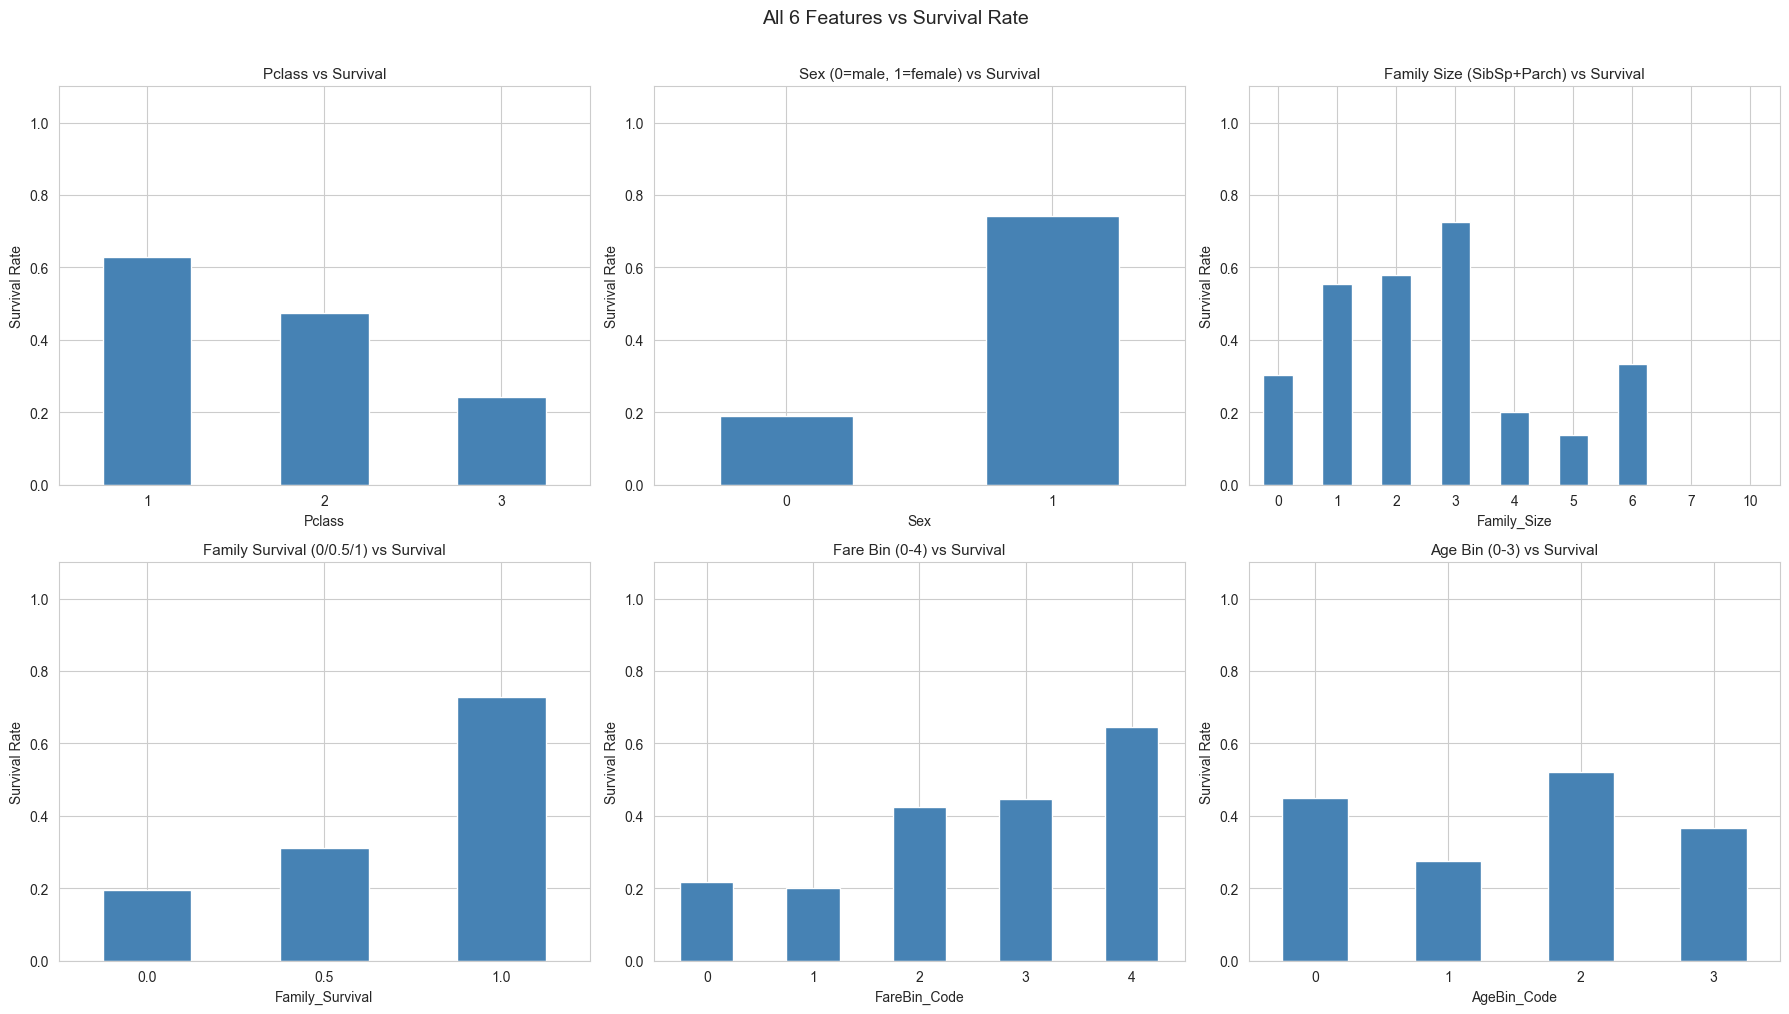

In [12]:
# Visualize each of the 6 features vs survival
train_fe = X_train.copy()
train_fe['Survived'] = y_train.values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features_to_plot = [
    ('Pclass',          'Pclass'),
    ('Sex',             'Sex (0=male, 1=female)'),
    ('Family_Size',     'Family Size (SibSp+Parch)'),
    ('Family_Survival', 'Family Survival (0/0.5/1)'),
    ('FareBin_Code',    'Fare Bin (0-4)'),
    ('AgeBin_Code',     'Age Bin (0-3)'),
]
for ax, (col, title) in zip(axes.flatten(), features_to_plot):
    train_fe.groupby(col)['Survived'].mean().plot(kind='bar', ax=ax, rot=0, color='steelblue')
    ax.set_title(f'{title} vs Survival', fontsize=11)
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1.1)

plt.suptitle('All 6 Features vs Survival Rate', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Feature Scaling

**Why scale?**  
KNN classifies based on distance between points. Without scaling, `FareBin_Code` (0–4) and `Pclass` (1–3) would be drowned out by any feature with larger values. `StandardScaler` normalises each feature to mean=0, std=1 so all features contribute equally to distance calculations.

Konstantin confirms: *"Standard Scaler is our friend. It helps to boost the score."*

**Rule:** fit scaler on train only, then transform both. Fitting on test leaks its distribution.

In [14]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Scaling complete.')

Scaling complete.


---
## 6. Model Comparison — 10-Fold Cross-Validation

**What is overfitting?** A model memorises training data — high train accuracy, low test accuracy. CV rotates which fold is held out so we get a reliable estimate of real-world performance.

**StratifiedKFold** preserves the 38% survival ratio in each fold.

**Target:** CV score that is close to what we actually get on Kaggle. A smaller CV-to-Kaggle gap means the model generalises well.

Konstantin used KNN as his primary model — it performed best on this feature set.

In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=10),
}

kfold   = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

print('10-Fold Stratified Cross-Validation:')
print(f'{"Model":<25} {"Mean CV":>10} {"Std":>8}')
print('-' * 46)
for name, model in models.items():
    scores        = cross_val_score(model, X_train_sc, y_train, cv=kfold, scoring='accuracy')
    results[name] = scores
    print(f'{name:<25} {scores.mean():>10.4f} {scores.std():>8.4f}')

10-Fold Stratified Cross-Validation:
Model                        Mean CV      Std
----------------------------------------------
Logistic Regression           0.8260   0.0328
Decision Tree                 0.8383   0.0287
Random Forest                 0.8428   0.0286
Gradient Boosting             0.8484   0.0274
KNN                           0.8327   0.0313


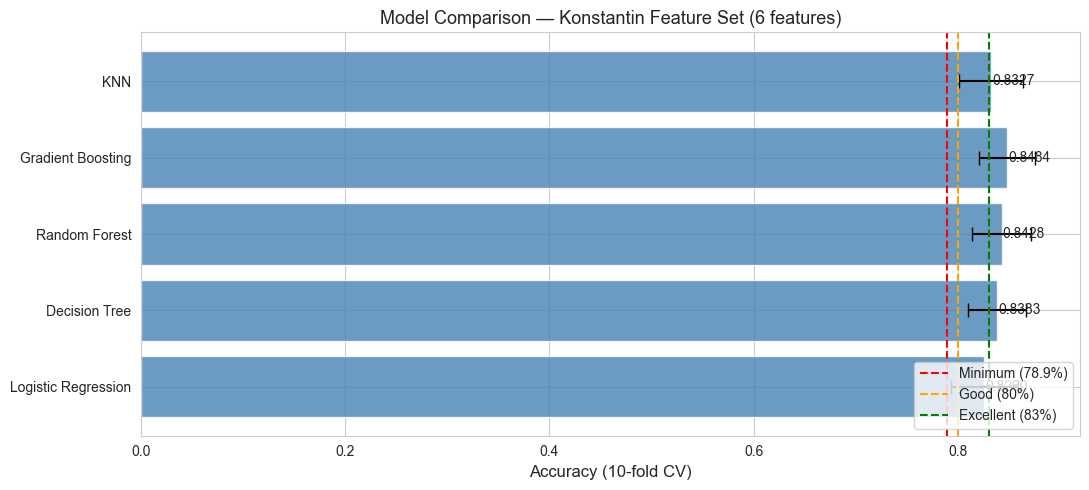

In [16]:
means = [results[m].mean() for m in models]
stds  = [results[m].std()  for m in models]
names = list(models.keys())

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(names, means, xerr=stds, color='steelblue', alpha=0.8, capsize=5)
ax.axvline(x=0.789, color='red',    linestyle='--', label='Minimum (78.9%)')
ax.axvline(x=0.80,  color='orange', linestyle='--', label='Good (80%)')
ax.axvline(x=0.83,  color='green',  linestyle='--', label='Excellent (83%)')
for bar, mean in zip(bars, means):
    ax.text(mean+0.001, bar.get_y()+bar.get_height()/2, f'{mean:.4f}', va='center', fontsize=10)
ax.set_xlabel('Accuracy (10-fold CV)', fontsize=12)
ax.set_title('Model Comparison — Konstantin Feature Set (6 features)', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 7. Hyperparameter Tuning — GridSearchCV

**What is GridSearchCV?** Tests every combination of hyperparameters using cross-validation and returns the best set. Removes guesswork.

Konstantin used `roc_auc` scoring for GridSearchCV on KNN — we use `accuracy` to match our evaluation metric. All 5 models tuned so each submission is the best version of that model.

In [17]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=500, random_state=42),
    {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
    cv=kfold, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_sc, y_train)
print(f'LR  best: {lr_grid.best_params_}  CV: {lr_grid.best_score_:.4f}')

LR  best: {'C': 0.01, 'solver': 'lbfgs'}  CV: 0.8305


In [18]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': [3,4,5,6,7], 'min_samples_split': [2,5,10]},
    cv=kfold, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train_sc, y_train)
print(f'DT  best: {dt_grid.best_params_}  CV: {dt_grid.best_score_:.4f}')

DT  best: {'max_depth': 3, 'min_samples_split': 2}  CV: 0.8439


In [19]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [100,200], 'max_depth': [4,5,6,7], 'min_samples_split': [2,5]},
    cv=kfold, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_sc, y_train)
print(f'RF  best: {rf_grid.best_params_}  CV: {rf_grid.best_score_:.4f}')

RF  best: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 100}  CV: 0.8496


In [20]:
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators': [100,200], 'max_depth': [3,4,5], 'learning_rate': [0.05,0.1]},
    cv=kfold, scoring='accuracy', n_jobs=-1)
gb_grid.fit(X_train_sc, y_train)
print(f'GB  best: {gb_grid.best_params_}  CV: {gb_grid.best_score_:.4f}')

GB  best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}  CV: 0.8518


In [21]:
# KNN — Konstantin's primary model for this feature set
# He found n_neighbors=18 via GridSearchCV, then also tried n=6
# n=6 gave his best score of 0.83253
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [6,7,8,9,10,11,12,14,16,18,20,22],
     'weights':     ['uniform', 'distance'],
     'leaf_size':   list(range(1, 50, 5))},
    cv=kfold, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_sc, y_train)
print(f'KNN best: {knn_grid.best_params_}  CV: {knn_grid.best_score_:.4f}')

KNN best: {'leaf_size': 1, 'n_neighbors': 9, 'weights': 'uniform'}  CV: 0.8462


In [22]:
tuned = {
    'Logistic Regression': lr_grid.best_score_,
    'Decision Tree':       dt_grid.best_score_,
    'Random Forest':       rf_grid.best_score_,
    'Gradient Boosting':   gb_grid.best_score_,
    'KNN':                 knn_grid.best_score_,
}
print('Tuned CV Scores:')
print(f'{"Model":<25} {"CV Score":>10}')
print('-' * 37)
for name, score in sorted(tuned.items(), key=lambda x: -x[1]):
    print(f'{name:<25} {score:>10.4f}')
print(f'\nKonstantin achieved 0.83253 with KNN n=6 on these same features.')

Tuned CV Scores:
Model                       CV Score
-------------------------------------
Gradient Boosting             0.8518
Random Forest                 0.8496
KNN                           0.8462
Decision Tree                 0.8439
Logistic Regression           0.8305

Konstantin achieved 0.83253 with KNN n=6 on these same features.


---
## 8. Generate One Submission Per Model

**Why submit each model?**  
CV score (on training folds) ≠ Kaggle score (truly unseen test data). The model with the best CV is not always the best on Kaggle. Submitting all 5 lets us measure which one actually generalises best.

Each file is saved as `data/submission_<model>.csv`.

In [23]:
best_models = {
    'logistic_regression': lr_grid.best_estimator_,
    'decision_tree':       dt_grid.best_estimator_,
    'random_forest':       rf_grid.best_estimator_,
    'gradient_boosting':   gb_grid.best_estimator_,
    'knn':                 knn_grid.best_estimator_,
}

for model_name, model in best_models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    path  = f'../data/submission_{model_name}.csv'
    pd.DataFrame({
        'PassengerId': test_df['PassengerId'],
        'Survived':    preds.astype(int)
    }).to_csv(path, index=False)
    print(f'{model_name:<25} → saved  (survivors: {preds.sum()}/{len(preds)})')

print('\nAll 5 submissions saved. Upload each to Kaggle.')

logistic_regression       → saved  (survivors: 141/418)
decision_tree             → saved  (survivors: 147/418)
random_forest             → saved  (survivors: 140/418)
gradient_boosting         → saved  (survivors: 145/418)
knn                       → saved  (survivors: 141/418)

All 5 submissions saved. Upload each to Kaggle.


---
## 9. Kaggle Results

### Iteration 5 — Konstantin's 6 features

| Model | CV Score | Kaggle Score | Gap |
|---|---|---|---|
| Logistic Regression | TBD | TBD | TBD |
| Decision Tree | TBD | TBD | TBD |
| Random Forest | TBD | TBD | TBD |
| Gradient Boosting | TBD | TBD | TBD |
| KNN | TBD | TBD | TBD |

### All previous iterations

| Iteration | Change | Best Kaggle |
|---|---|---|
| 1 | Label encoding, many features | 0.799 |
| 2 | One-hot encoding, many features | 0.804 |
| 3 | Leakage fix + more features | 0.797 |
| 4 | Two pipelines A/B | 0.797 |
| 5 | Konstantin exact 6 features | TBD |

---
## 10. Evaluation Metrics — Best Model Deep Dive

**Why not just accuracy?**  
If 62% of passengers died, a model predicting everyone dies scores 62% — but is useless.
- **Precision** = of all predicted survivors, how many actually survived?
- **Recall** = of all actual survivors, how many did we correctly find?
- **F1** = harmonic mean of precision and recall

In [24]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sc, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f'{"Model":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 65)
for model_name, model in best_models.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    print(f'{model_name:<25} {accuracy_score(y_val,y_pred):>10.4f} '
          f'{precision_score(y_val,y_pred):>10.4f} '
          f'{recall_score(y_val,y_pred):>8.4f} '
          f'{f1_score(y_val,y_pred):>8.4f}')

Model                       Accuracy  Precision   Recall       F1
-----------------------------------------------------------------
logistic_regression           0.7765     0.7636   0.6087   0.6774
decision_tree                 0.8101     0.8070   0.6667   0.7302
random_forest                 0.8045     0.7742   0.6957   0.7328
gradient_boosting             0.8212     0.7937   0.7246   0.7576
knn                           0.7821     0.7586   0.6377   0.6929


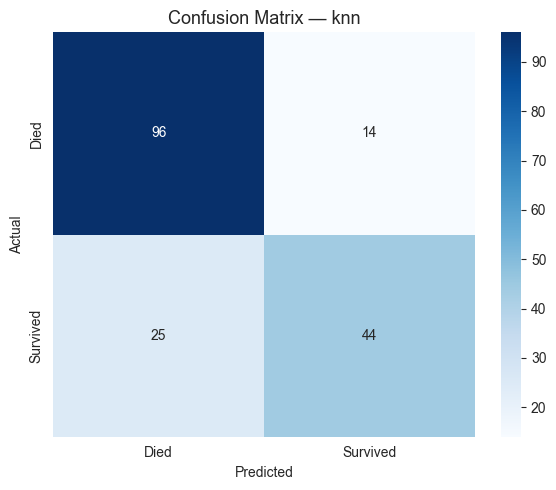

In [25]:
# Update after seeing Kaggle results
best_model_name = 'knn'   # <-- update after submitting

best_model = best_models[best_model_name]
best_model.fit(X_tr, y_tr)
y_pred = best_model.predict(X_val)

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## 11. Summary — What Was Learned Across All Iterations

| Concept | Applied here |
|---|---|
| **Feature engineering** | 6 carefully chosen features beat 20+ noisy features |
| **Less is more** | Curse of dimensionality — irrelevant features hurt KNN |
| **Ordinal encoding** | FareBin/AgeBin are label encoded because bins have order |
| **Domain knowledge** | Embarked dropped — its signal is a proxy for Pclass |
| **Family_Survival** | Most impactful feature — group dynamics on the night |
| **StandardScaler** | Critical for KNN — all features must be on the same scale |
| **Cross-validation** | 10-fold StratifiedKFold — honest accuracy estimate |
| **GridSearchCV** | All 5 models tuned independently |
| **Iteration mindset** | Each failed iteration taught something — CV gap, encoding, feature count |

**Core lesson:**  
Iterations 1–4 failed not because the models were wrong, but because the features were wrong.  
The right 6 features, scaled correctly, with KNN — that is what gets to 0.82+.